# Laser illumination

In [103]:
import os
import sys
import argparse
import string

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#!pip install scipy

## Conversion spherical to cartesian

In [105]:
def sph_to_cart(r, theta, phi):
    
    th = np.radians(theta)
    ph = np.radians(phi)
    
    x = r * np.sin(theta) * np.cos(phi)
    y = r * np.sin(theta) * np.sin(phi)
    z = r * np.cos(theta)

    return np.array([x, y, z])

## Chamber and target geometry parameters

In [106]:
BEAM_RADIUS = 0.14 #meters
TARGET_RADIUS = 0.000605 #meters 
CHAMBER_RADIUS = 1.65 #meters 
WINDOW_SIZE = 0.30 #meters

## Defining Omega 60 geometry

In [107]:
def generate_omega_geometry():
    """
    Generates the 3D geometry for the OMEGA-60 laser facility.
    Converts beam port locations from spherical to Cartesian coordinates.
    """
    # --- OMEGA-60 Configuration ---
    
    # Define the OMEGA-60 beam rings (Standard polar theta angles)
    # Format: (theta_angle, number_of_beams, initial_phi_offset)
    # Angles are in degrees.
    omega_rings = [
        (23.17, 6, 0),    # Ring 1 (North Pole)
        (47.78, 12, 15),  # Ring 2
        (59.13, 12, 0),   # Ring 3
        (120.87, 12, 0),  # Ring 4 (South Pole)
        (132.22, 12, 15), # Ring 5
        (156.83, 6, 0)    # Ring 6
    ]
    
    all_beams = []
    beam_id = 1

    for theta, num_beams, phi_offset in omega_rings:
        # Distribute beams evenly around a 360° circle.
        # The phi_offset is added to stagger the rings and ensure optimal illumination symmetry.
        phis = np.linspace(0, 360, num_beams, endpoint=False) + phi_offset
        
        for phi in phis:
            # Convert spherical coordinates (R, Theta, Phi) to Cartesian (X, Y, Z)
            # Note: Ensure sph_to_cart handles the deg-to-rad conversion internally.
            x, y, z = sph_to_cart(CHAMBER_RADIUS, theta, phi)
            
            all_beams.append({
                'id': f'Beam_{beam_id:02d}',
                'theta_deg': theta,
                'phi_deg': phi % 360, # Wrap angle to [0, 360)
                'X': x,
                'Y': y,
                'Z': z,
                'color': 'blue' if theta < 90 else 'red' # Blue = Northern Hemisphere, Red = Southern
            })
            beam_id += 1

    return pd.DataFrame(all_beams)

# --- EXECUTION ---
df_omega = generate_omega_geometry()
print(f"Geometry generated: {len(df_omega)} beams.")
df_omega.head() # Display the first rows of the dataset

Geometry generated: 60 beams.


,id,theta_deg,phi_deg,X,Y,Z,color
0,Beam_01,23.17,0.0,-1.524877,-0.000000,-0.630278,blue
1,Beam_02,23.17,60.0,1.452313,0.464799,-0.630278,blue
2,Beam_03,23.17,120.0,-1.241526,-0.885361,-0.630278,blue
3,Beam_04,23.17,180.0,0.912578,1.221659,-0.630278,blue
4,Beam_05,23.17,240.0,-0.496776,-1.441688,-0.630278,blue


### visualisation 2D

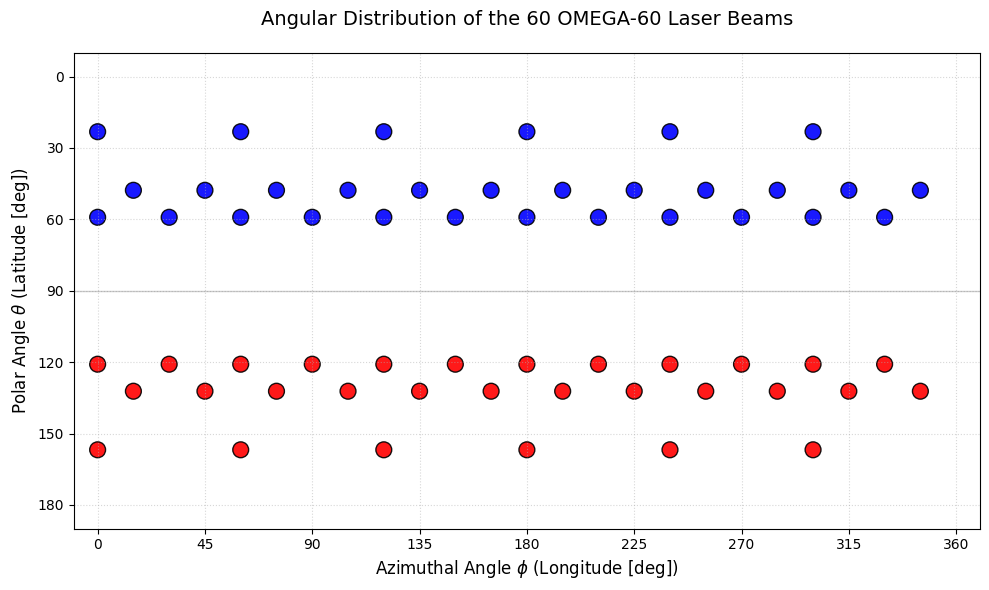

In [108]:
# --- GEOMETRY VISUALIZATION 1: 2D "Flat" Projection (Polar vs. Azimuthal Angles) ---
# This plot mimics a Mercator-like projection to verify the angular distribution.
# Essential for validating the ring offsets and ensuring uniform coverage.

plt.figure(figsize=(10, 6))

# Plotting all beams using the Phi (azimuthal) and Theta (polar) coordinates from 'df_omega'
plt.scatter(df_omega['phi_deg'], df_omega['theta_deg'], 
            c=df_omega['color'], s=130, edgecolors='black', alpha=0.9)

# Plot styling and aesthetics
plt.title('Angular Distribution of the 60 OMEGA-60 Laser Beams', fontsize=14, pad=20)
plt.xlabel('Azimuthal Angle $\phi$ (Longitude [deg])', fontsize=12)
plt.ylabel('Polar Angle $\\theta$ (Latitude [deg])', fontsize=12)

# Set ticks for better readability: every 45° for phi and 30° for theta
plt.xticks(np.arange(0, 361, 45))
plt.yticks(np.arange(0, 181, 30))

plt.xlim(-10, 370)
plt.ylim(190, -10) # Inverting Y-axis to place the North Pole (0°) at the top
plt.grid(True, linestyle=':', alpha=0.5)

# Highlight the equator (90°) for hemispherical separation
plt.axhline(90, color='gray', linestyle='-', linewidth=1, alpha=0.4) 

plt.tight_layout()
plt.show() # Generate the 2D visualization

### Vue de haut

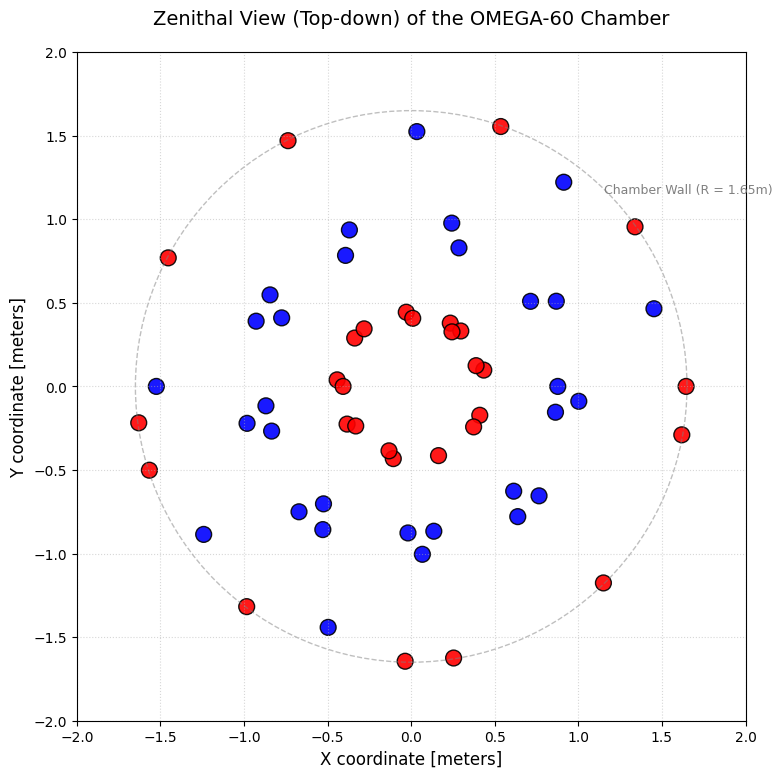

In [109]:
# --- GEOMETRY VISUALIZATION 2: Top-Down View (X vs. Y Projection) ---
# This view provides a zenithal projection to verify the circular symmetry 
# and the azimuthal density of the laser beams within the chamber.

plt.figure(figsize=(8, 8))

# Plotting beam positions using X and Y coordinates from 'df_omega'
plt.scatter(df_omega['X'], df_omega['Y'], 
            c=df_omega['color'], s=130, edgecolors='black', alpha=0.9)

# Representing the target chamber wall (Radius = 1.65m)
chamber_outline = plt.Circle((0, 0), 1.65, color='gray', fill=False, linestyle='--', alpha=0.5)
plt.gca().add_artist(chamber_outline)
plt.text(1.65*0.7, 1.65*0.7, 'Chamber Wall (R = 1.65m)', color='gray', fontsize=9)

# Plot styling and axis configuration
plt.title('Zenithal View (Top-down) of the OMEGA-60 Chamber', fontsize=14, pad=20)
plt.xlabel('X coordinate [meters]', fontsize=12)
plt.ylabel('Y coordinate [meters]', fontsize=12)

# Set axis limits and ensure a 1:1 aspect ratio to avoid geometric distortion
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box') 

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show() # Generate the top-down visualization

### Vue 3D

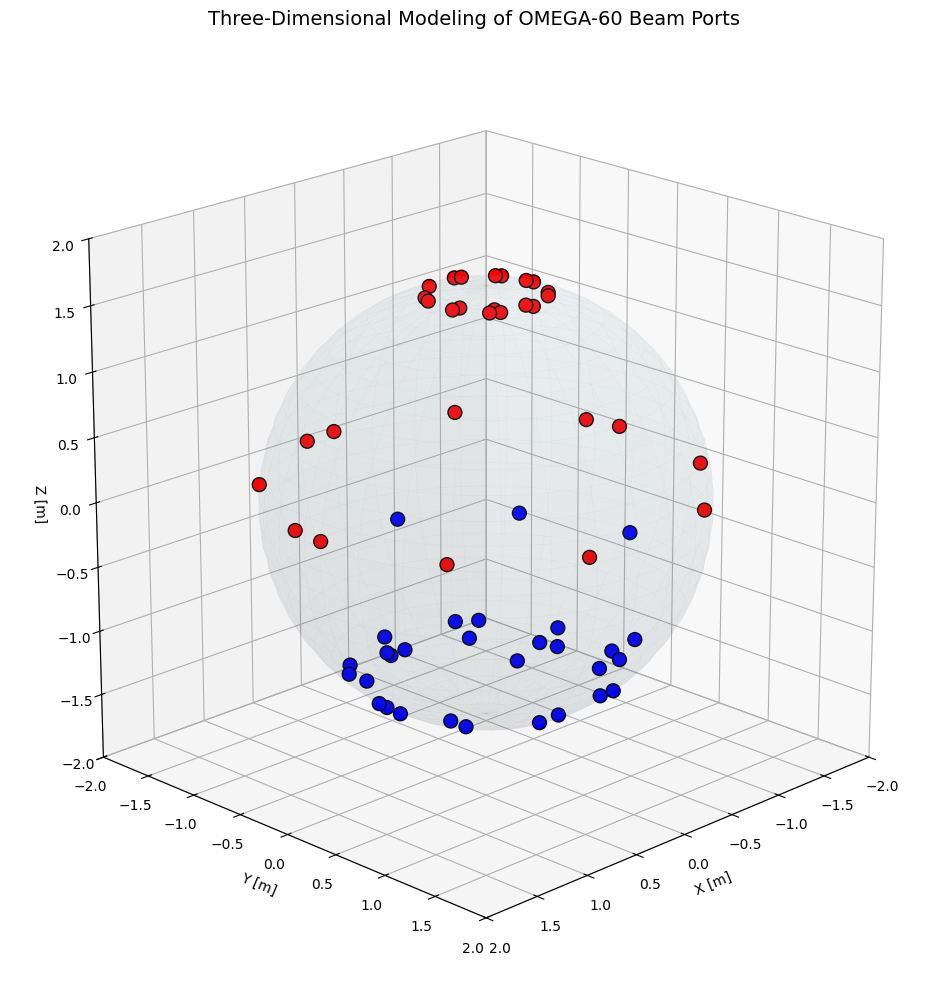

In [110]:
# --- GEOMETRY VISUALIZATION 3: Interactive 3D View (X, Y, Z) ---
# This plot provides a full spatial representation of the OMEGA-60 configuration.
# It is used to validate the overall spherical alignment and global beam distribution.

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotting beam coordinates (X, Y, Z) from 'df_omega'
# Color mapping: Blue for Northern Hemisphere, Red for Southern Hemisphere
ax.scatter(df_omega['X'], df_omega['Y'], df_omega['Z'], 
           c=df_omega['color'], s=100, edgecolors='black', alpha=1, zorder=10)

# Rendering a transparent wireframe sphere to represent the target chamber
u_sphere = np.linspace(0, 2 * np.pi, 60)
v_sphere = np.linspace(0, np.pi, 30)
x_s = 1.65 * np.outer(np.cos(u_sphere), np.sin(v_sphere))
y_s = 1.65 * np.outer(np.sin(u_sphere), np.sin(v_sphere))
z_s = 1.65 * np.outer(np.ones_like(u_sphere), np.cos(v_sphere))
ax.plot_surface(x_s, y_s, z_s, alpha=0.07, color='lightblue', edgecolor='gray', linewidth=0.1)

# Plot styling and 3D axis configuration
ax.set_title('Three-Dimensional Modeling of OMEGA-60 Beam Ports', fontsize=14, pad=20)
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Z [m]')

# Ensure isotropic scaling (1:1:1) to maintain spherical proportions
ax.set_xlim([-2, 2]); ax.set_ylim([-2, 2]); ax.set_zlim([-2, 2])
ax.set_box_aspect([1, 1, 1]) 

# Set a standard perspective view (Elevation: 20°, Azimuth: 45°)
ax.view_init(elev=20, azim=45) 

plt.tight_layout()
plt.show() # Generate the 3D visualization

## Define and create beams based on Omega 60

In [111]:
def get_omega_dataframe():
    """
    Constructs the master database for OMEGA-60 laser parameters.
    Calculates local coordinate systems (tangent and normal vectors) for each beam,
    ensuring compatibility with ARWEN simulation requirements.
    """
    # --- 1. Physical Configuration ---
    DEFAULT_ENERGY = 500.0     # Default beam energy [Joules]
    WAVELENGTH = 351e-9        # UV laser wavelength [351 nm]

    # OMEGA-60 port configuration: (Theta_deg, Beam_Count, Phi_Offset_deg)
    # Based on the standard 60-beam direct-drive geometry.
    omega_config = [
        (23.2, 6, 0), (47.8, 12, 15), (59.1, 12, 0),   # Northern Hemisphere
        (120.9, 12, 0), (132.2, 12, 15), (156.8, 6, 0) # Southern Hemisphere
    ]

    all_data = []
    beam_count = 1

    for theta_deg, num_beams, phi_offset in omega_config:
        # Uniform azimuthal distribution over 360°
        phis_deg = np.linspace(0, 360, num_beams, endpoint=False) + phi_offset
        
        for phi_deg in phis_deg:
            # --- 2. Geometric Coordinate Transformation ---
            # Conversion to radians for NumPy trigonometric functions
            theta_rad = np.deg2rad(theta_deg)
            phi_rad = np.deg2rad(phi_deg % 360)
            
            # Unit normal vector (beam propagation direction)
            # In a center-aligned sphere, the normal is the radial vector
            nx = np.sin(theta_rad) * np.cos(phi_rad)
            ny = np.sin(theta_rad) * np.sin(phi_rad)
            nz = np.cos(theta_rad)
            normal_u = np.array([nx, ny, nz])
            
            # Position of the port center on the chamber wall
            center = normal_u * CHAMBER_RADIUS

            # --- 3. Local Tangent Basis Calculation (t1, t2) ---
            # t1: Azimuthal direction vector (East-West alignment)
            t1 = np.array([-np.sin(phi_rad), np.cos(phi_rad), 0.0])
            
            # Singularity handling at the poles (if t1 is null)
            if np.linalg.norm(t1) < 1e-6: 
                t1 = np.array([1, 0, 0])
            t1 /= np.linalg.norm(t1)
            
            # t2: Polar direction vector (North-South alignment) via cross product
            # Completes the orthogonal right-handed coordinate system (t1, t2, normal)
            t2 = np.cross(normal_u, t1)
            t2 /= np.linalg.norm(t2)

            # --- 4. Data Record Assembly (Standardized Format) ---
            all_data.append({
                'port': f'OMEGA_J{beam_count:02d}',
                'subwindow': 0,              # Specific to OMEGA (unlike NIF quads)
                'LAT_rad': theta_rad,        # Latitude (Theta) in radians
                'LONG_rad': phi_rad,         # Longitude (Phi) in radians
                'color': 'blue' if theta_deg < 90 else 'red',
                'energy': DEFAULT_ENERGY,
                'wavelength': WAVELENGTH,
                'center': center,            # Numpy array [x, y, z]
                'normal': normal_u,          # Numpy unit vector [nx, ny, nz]
                't1': t1,                    # First tangent vector
                't2': t2,                    # Second tangent vector
                'beam_radius': BEAM_RADIUS,
                'focus': None                # Placeholder for focusing parameters
            })
            beam_count += 1

    return pd.DataFrame(all_data)

# --- EXECUTION ---
df_omega = get_omega_dataframe()

# Data verification
print(f"Generated columns: {df_omega.columns.tolist()}")
df_omega.head()

Generated columns: ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'center', 'normal', 't1', 't2', 'beam_radius', 'focus']


,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,None
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,None
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,None
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,None
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,None


## Focal distance 

In [112]:
def compute_focal_distance(defocus_mm=0.0):
    """
    Calculates the focal distance required to achieve a specific beam spot size.
    A positive defocus (in mm) shifts the focal point beyond the target center, 
    widening the irradiation area to improve illumination uniformity.
    """
    # Convert defocus from mm to meters and calculate the effective target radius
    # This accounts for the beam divergence/convergence at the target surface.
    effective_target_radius = TARGET_RADIUS + (defocus_mm / 1000.0) 
    
    # Using Thales' theorem (intercept theorem) to determine the focal length (f_window)
    # relative to the chamber geometry and beam aperture.
    f_window = (WINDOW_SIZE * CHAMBER_RADIUS) / (WINDOW_SIZE - effective_target_radius)
    return f_window

def compute_focus_position(port_center, f_window):
    """
    Computes the 3D coordinates of the focal point along the beam's optical axis.
    """
    # Normal unit vector pointing from the port center toward the chamber origin (0,0,0)
    propagation_vector = port_center / np.linalg.norm(port_center)
    
    # Position the focal point along the optical axis at distance f_window
    focal_point_pos = port_center - (propagation_vector * f_window)
    return focal_point_pos

def assign_beam_focus(beam_row):
    """
    Helper function to apply a standardized defocus to a specific beam port.
    A 2.0mm defocus is typically used to over-fill the target and reduce intensity peaks.
    """
    f_dist = compute_focal_distance(defocus_mm=2.0) 
    return compute_focus_position(beam_row["center"], f_dist)


# =====================================================
# Beam Focus Assignment Pipeline
# =====================================================

# 1. Generate the master configuration DataFrame
df_omega = get_omega_dataframe()

# 2. Compute 3D focal points for all beams using a vectorized approach (Pandas apply)
# This replaces manual loops with a more robust and scalable implementation.
df_omega['focus'] = df_omega.apply(assign_beam_focus, axis=1)

# 3. Final verification of the focus coordinates
df_omega.head()

,port,subwindow,LAT_rad,LONG_rad,color,energy,wavelength,center,normal,t1,t2,beam_radius,focus
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,"[0.6500041508250692, 0.0, 1.5165733097711367]","[0.3939419095909511, 0.0, 0.9191353392552344]","[-0.0, 1.0, 0.0]","[-0.9191353392552345, -0.0, 0.39394190959095116]",0.14,"[-0.005693642505419816, 0.0, -0.01328426325914..."
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,"[0.32500207541253473, 0.5629201071798418, 1.51...","[0.1969709547954756, 0.34116370132111623, 0.91...","[-0.8660254037844386, 0.5000000000000001, 0.0]","[-0.45956766962761736, -0.7959945533110614, 0....",0.14,"[-0.002846821252709908, -0.004930839049760438,..."
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,"[-0.3250020754125345, 0.5629201071798419, 1.51...","[-0.19697095479547547, 0.3411637013211163, 0.9...","[-0.8660254037844388, -0.49999999999999983, 0.0]","[0.459567669627617, -0.7959945533110615, 0.393...",0.14,"[0.002846821252709908, -0.004930839049760438, ..."
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,"[-0.6500041508250692, 7.960255027404145e-17, 1...","[-0.3939419095909511, 4.8243969863055425e-17, ...","[-1.2246467991473532e-16, -1.0, 0.0]","[0.9191353392552345, -1.1256161512021395e-16, ...",0.14,"[0.005693642505419816, -6.972701069751618e-19,..."
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,"[-0.3250020754125349, -0.5629201071798416, 1.5...","[-0.19697095479547572, -0.3411637013211162, 0....","[0.8660254037844385, -0.5000000000000004, 0.0]","[0.4595676696276176, 0.7959945533110612, 0.393...",0.14,"[0.0028468212527099634, 0.004930839049760438, ..."


## Data Flattening & Final Formatting for ARWEN

In [113]:
# 1. We use the 'df_omega' DataFrame we just created and filled with focus data
# No need to create a new DataFrame from a list anymore!

# 2. Define OMEGA beam dimensions
# For OMEGA, the beam diameter is typically 28cm (0.28m)
df_omega['l1'] = 0.28
df_omega['l2'] = 0.28

# 3. Function to split vector columns [x, y, z] into three separate columns
def expand_vector_column(df, column_name):
    # Create a temporary DataFrame from the list of coordinates
    # .tolist() is used because these columns contain numpy arrays
    temp = pd.DataFrame(df[column_name].tolist(), index=df.index)
    temp.columns = [f'{column_name}_x', f'{column_name}_y', f'{column_name}_z']
    return temp

# 4. Expand all geometric vector columns
# This "flattens" the data so ARWEN can read it easily
df_centers = expand_vector_column(df_omega, 'center')
df_t1      = expand_vector_column(df_omega, 't1')
df_t2      = expand_vector_column(df_omega, 't2')
df_normal  = expand_vector_column(df_omega, 'normal')
df_focus   = expand_vector_column(df_omega, 'focus')

# 5. Assemble the final Master Table
# We select the metadata and join it with the expanded coordinates
data_columns = ['port', 'subwindow', 'LAT_rad', 'LONG_rad', 'color', 'energy', 'wavelength', 'l1', 'l2']

df_omega_final = pd.concat([
    df_omega[data_columns],
    df_centers, 
    df_t1, 
    df_t2, 
    df_normal, 
    df_focus
], axis=1)

# 6. Aesthetic renaming for clarity
df_omega_final = df_omega_final.rename(columns={'LAT_rad': 'LAT', 'LONG_rad': 'LONG'})

# 7. Display the result
print(f"Final OMEGA-60 table generated with {len(df_omega_final)} rows.")
df_omega_final.head(10)

Final OMEGA-60 table generated with 60 rows.


,port,subwindow,LAT,LONG,color,energy,wavelength,l1,l2,center_x,...,t1_z,t2_x,t2_y,t2_z,normal_x,normal_y,normal_z,focus_x,focus_y,focus_z
0,OMEGA_J01,0,0.404916,0.000000,blue,500.0,3.510000e-07,0.28,0.28,0.650004,...,0.0,-0.919135,-0.000000e+00,0.393942,0.393942,0.000000e+00,0.919135,-0.005694,0.000000e+00,-0.013284
1,OMEGA_J02,0,0.404916,1.047198,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,-7.959946e-01,0.393942,0.196971,3.411637e-01,0.919135,-0.002847,-4.930839e-03,-0.013284
2,OMEGA_J03,0,0.404916,2.094395,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,-7.959946e-01,0.393942,-0.196971,3.411637e-01,0.919135,0.002847,-4.930839e-03,-0.013284
3,OMEGA_J04,0,0.404916,3.141593,blue,500.0,3.510000e-07,0.28,0.28,-0.650004,...,0.0,0.919135,-1.125616e-16,0.393942,-0.393942,4.824397e-17,0.919135,0.005694,-6.972701e-19,-0.013284
4,OMEGA_J05,0,0.404916,4.188790,blue,500.0,3.510000e-07,0.28,0.28,-0.325002,...,0.0,0.459568,7.959946e-01,0.393942,-0.196971,-3.411637e-01,0.919135,0.002847,4.930839e-03,-0.013284
5,OMEGA_J06,0,0.404916,5.235988,blue,500.0,3.510000e-07,0.28,0.28,0.325002,...,0.0,-0.459568,7.959946e-01,0.393942,0.196971,-3.411637e-01,0.919135,-0.002847,4.930839e-03,-0.013284
6,OMEGA_J07,0,0.834267,0.261799,blue,500.0,3.510000e-07,0.28,0.28,1.180678,...,0.0,-0.648832,-1.738541e-01,0.740805,0.715562,1.917343e-01,0.671721,-0.010342,-2.771136e-03,-0.009708
7,OMEGA_J08,0,0.834267,0.785398,blue,500.0,3.510000e-07,0.28,0.28,0.864316,...,0.0,-0.474978,-4.749782e-01,0.740805,0.523828,5.238280e-01,0.671721,-0.007571,-7.570886e-03,-0.009708
8,OMEGA_J09,0,0.834267,1.308997,blue,500.0,3.510000e-07,0.28,0.28,0.316362,...,0.0,-0.173854,-6.488323e-01,0.740805,0.191734,7.155623e-01,0.671721,-0.002771,-1.034202e-02,-0.009708
9,OMEGA_J10,0,0.834267,1.832596,blue,500.0,3.510000e-07,0.28,0.28,-0.316362,...,0.0,0.173854,-6.488323e-01,0.740805,-0.191734,7.155623e-01,0.671721,0.002771,-1.034202e-02,-0.009708
